# Experiment: Standalone Hologram Opening Example

Objective:

- Show how to import and use `hologram_opening.py` directly outside the app.
- Run `open_hologram_2d()` on either a user-provided dataset folder or a synthetic complex hologram.
- Compare one-sideband and two-sideband reconstruction outputs and visualize the returned stages.


In [4]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd().resolve()
assert (repo_root / "hologram_opening.py").exists(), "Start Jupyter from the repository root."
sys.path.insert(0, str(repo_root))

from hologram_opening import PROCESSING_MODES, open_hologram_2d, processed_phase
from processing import load_passage

plt.rcParams["figure.figsize"] = (14, 10)
plt.rcParams["image.cmap"] = "viridis"
np.set_printoptions(precision=4, suppress=True)

print(f"Using repo root: {repo_root}")
print(PROCESSING_MODES)


Using repo root: /Users/edoardolab/Documents/GitHub/SNOM_synthetic_holography_preview_app
{'one_sideband': 'One Sideband', 'two_sideband': 'Two Sidebands'}


## Plan

- Optionally load a real dataset folder and extract one complex harmonic image.
- Fall back to a synthetic complex hologram if no folder is provided.
- Call `open_hologram_2d()` directly in both processing modes.
- Inspect the returned `processed`, `mag_signal_ft`, and `filtered_shift` stages.
- Compute display-ready processed phase with `processed_phase()`.


In [5]:
folder_path = "/Users/edoardolab/Downloads/2026-03-24 171434 AFM 2.52THz_B"
passage = "forward"
harmonic_index = 4

pad_fact = 1
alpha = 0.3
carrier_row_override = None
filter_width_override = None

folder_path = folder_path.strip()
if folder_path:
    loaded = load_passage(folder_path, passage=passage, processing_mode="two_sideband")
    source_label = f"real dataset: {loaded.image_name} ({passage}, harmonic {harmonic_index})"
    input_hologram = loaded.o[:, :, harmonic_index]
else:
    ny, nx = 128, 128
    carrier_cycles = -24
    synthetic_carrier_row_override = 40
    synthetic_filter_width_override = 14

    x = np.linspace(-1.0, 1.0, nx)[None, :]
    y = np.linspace(-1.0, 1.0, ny)[:, None]

    amplitude = 1.0 + 0.25 * np.exp(-((x + 0.25) ** 2 + (y - 0.10) ** 2) / 0.08)
    amplitude += 0.18 * np.exp(-((x - 0.30) ** 2 + (y + 0.20) ** 2) / 0.03)
    phase = 0.9 * np.exp(-((x - 0.15) ** 2 + (y + 0.10) ** 2) / 0.09)
    phase += 0.4 * np.sin(2.0 * np.pi * x) * np.exp(-(y**2) / 0.6)

    object_field = amplitude * np.exp(1j * phase)
    carrier = np.exp(1j * 2.0 * np.pi * carrier_cycles * np.arange(ny)[:, None] / ny)
    input_hologram = object_field * carrier
    source_label = "synthetic example"
    if carrier_row_override is None:
        carrier_row_override = synthetic_carrier_row_override
    if filter_width_override is None:
        filter_width_override = synthetic_filter_width_override

print({
    "source": source_label,
    "shape": input_hologram.shape,
    "pad_fact": pad_fact,
    "alpha": alpha,
    "carrier_row_override": carrier_row_override,
    "filter_width_override": filter_width_override,
})


{'source': 'real dataset: 2026-03-24 171434 AFM 2.52THz_B (forward, harmonic 4)', 'shape': (800, 200), 'pad_fact': 1, 'alpha': 0.3, 'carrier_row_override': None, 'filter_width_override': None}


## Standalone Usage

The actual hologram opening below is fully standalone and comes from `hologram_opening.py`.
If `folder_path` is set, `processing.load_passage()` is used only to load the dataset and extract one complex harmonic image.


In [6]:
open_kwargs = {
    "pad_fact": pad_fact,
    "alpha": alpha,
    "processing_mode": "one_sideband",
}
if carrier_row_override is not None:
    open_kwargs["carrier_row"] = carrier_row_override
if filter_width_override is not None:
    open_kwargs["filter_width_y"] = filter_width_override

one_sideband_stages, one_carrier_row, one_filter_width, one_diag = open_hologram_2d(
    input_hologram,
    **open_kwargs,
)

open_kwargs["processing_mode"] = "two_sideband"

two_sideband_stages, two_carrier_row, two_filter_width, two_diag = open_hologram_2d(
    input_hologram,
    **open_kwargs,
)

summary = {
    "one_sideband": {
        "carrier_row": one_carrier_row,
        "filter_width_y": one_filter_width,
        **one_diag,
    },
    "two_sideband": {
        "carrier_row": two_carrier_row,
        "filter_width_y": two_filter_width,
        **two_diag,
    },
}
summary


{'one_sideband': {'carrier_row': 190,
  'filter_width_y': 190,
  'rotation_angle_rad': nan,
  'rotation_angle_deg': nan,
  'mirror_row': -1},
 'two_sideband': {'carrier_row': 191,
  'filter_width_y': 192,
  'rotation_angle_rad': 0.9685022842485439,
  'rotation_angle_deg': 55.491093336221155,
  'mirror_row': 609}}

## Results

- The raw input hologram is shown first.
- Then the standalone one-sideband and two-sideband outputs are visualized with the processed amplitude and display-ready processed phase.
- `mag_signal_ft` and `filtered_shift` come directly from the standalone function return value.


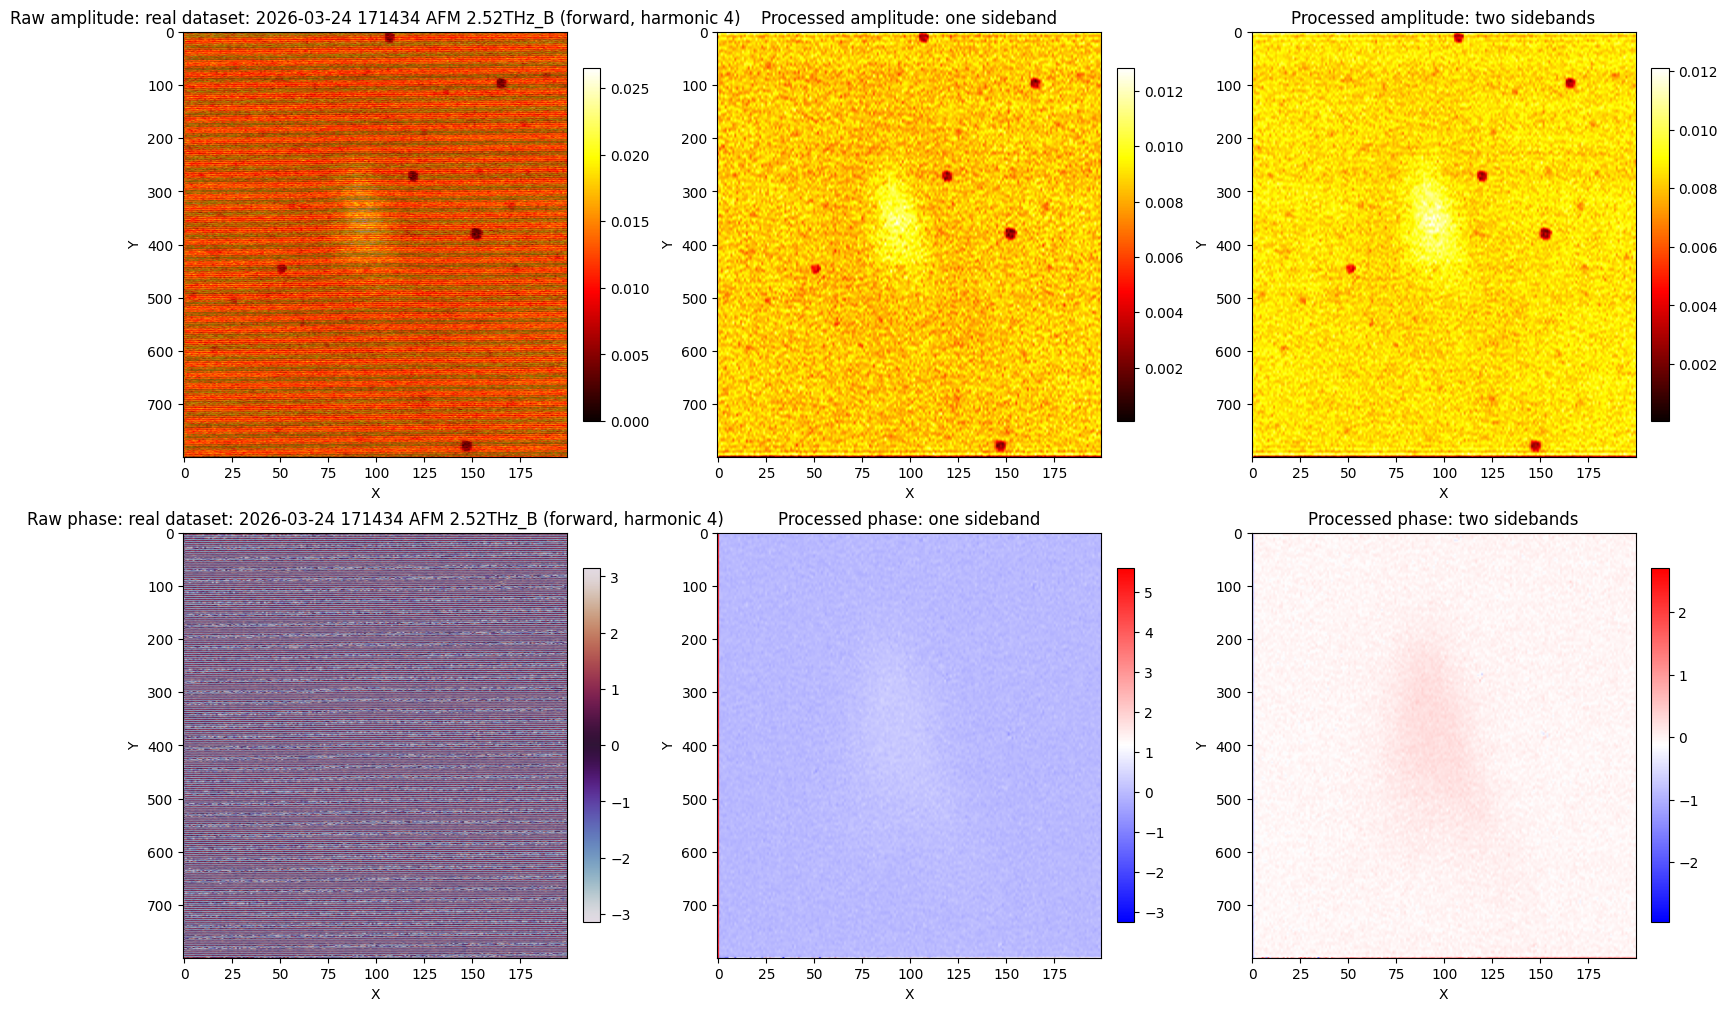

In [7]:
raw_amplitude = np.abs(input_hologram)
raw_phase = np.angle(input_hologram)

one_processed = one_sideband_stages["processed"]
two_processed = two_sideband_stages["processed"]

one_amp = np.abs(one_processed)
two_amp = np.abs(two_processed)
one_phase = processed_phase(one_processed, processing_mode="one_sideband")
two_phase = processed_phase(two_processed, processing_mode="two_sideband")

fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)
plots = [
    (raw_amplitude, f"Raw amplitude: {source_label}", "hot"),
    (one_amp, "Processed amplitude: one sideband", "hot"),
    (two_amp, "Processed amplitude: two sidebands", "hot"),
    (raw_phase, f"Raw phase: {source_label}", "twilight"),
    (one_phase, "Processed phase: one sideband", "bwr"),
    (two_phase, "Processed phase: two sidebands", "bwr"),
]
for axis, (image, title, cmap) in zip(axes.ravel(), plots):
    im = axis.imshow(image, aspect="auto", cmap=cmap)
    axis.set_title(title)
    axis.set_xlabel("X")
    axis.set_ylabel("Y")
    fig.colorbar(im, ax=axis, fraction=0.046, pad=0.04)
plt.show()


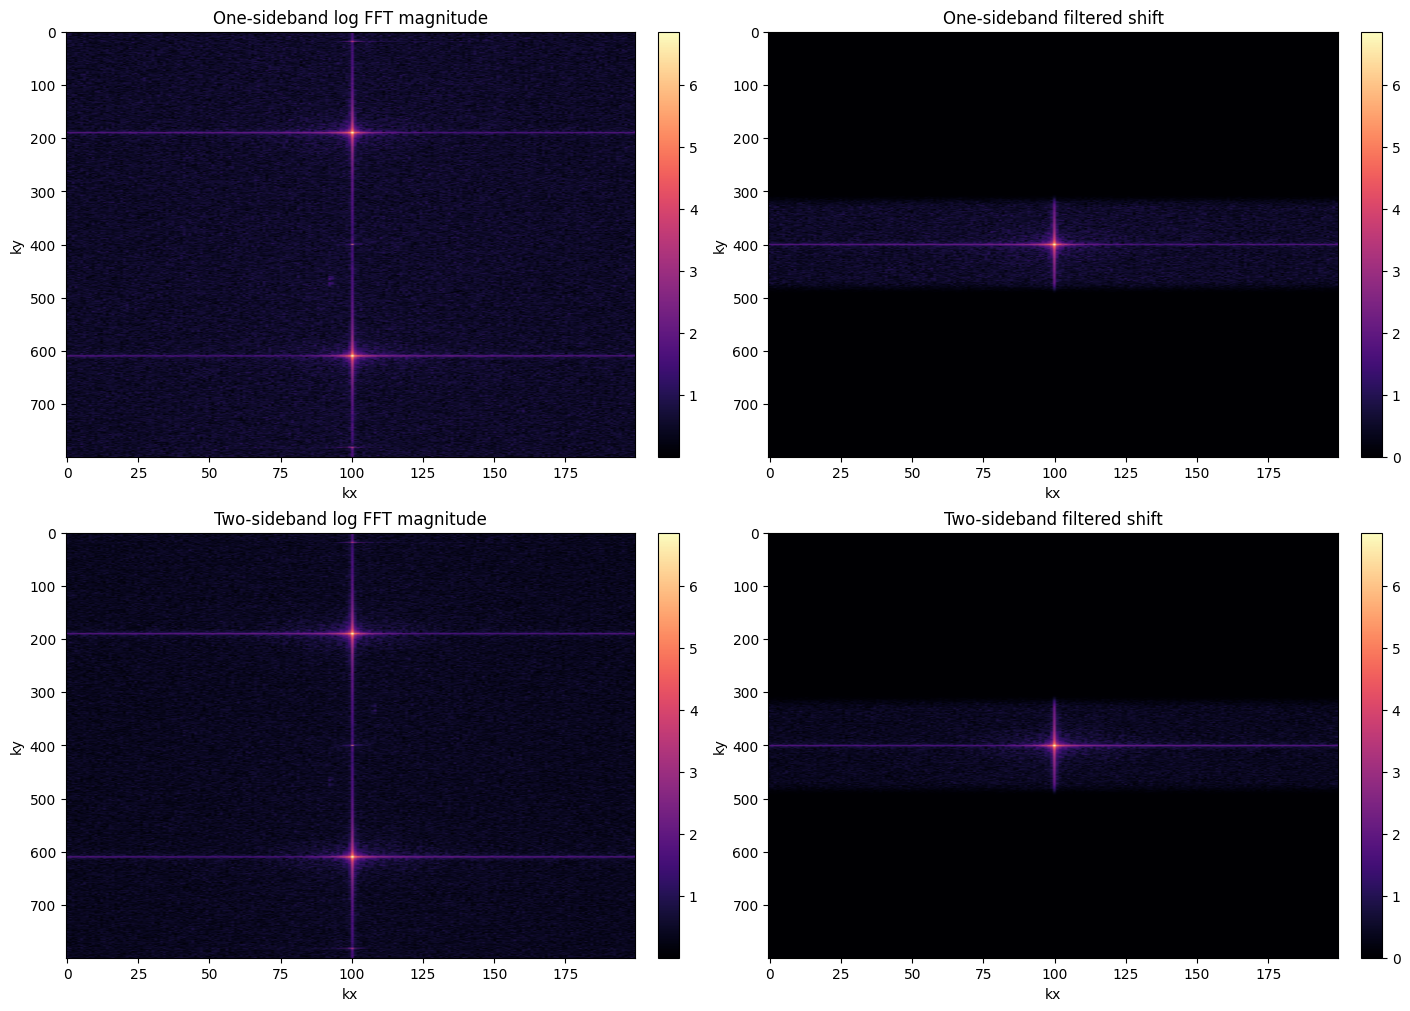

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
stage_plots = [
    (np.log1p(one_sideband_stages["mag_signal_ft"]), "One-sideband log FFT magnitude", "magma"),
    (np.log1p(np.abs(one_sideband_stages["filtered_shift"])), "One-sideband filtered shift", "magma"),
    (np.log1p(two_sideband_stages["mag_signal_ft"]), "Two-sideband log FFT magnitude", "magma"),
    (np.log1p(np.abs(two_sideband_stages["filtered_shift"])), "Two-sideband filtered shift", "magma"),
]
for axis, (image, title, cmap) in zip(axes.ravel(), stage_plots):
    im = axis.imshow(image, aspect="auto", cmap=cmap)
    axis.set_title(title)
    axis.set_xlabel("kx")
    axis.set_ylabel("ky")
    fig.colorbar(im, ax=axis, fraction=0.046, pad=0.04)
plt.show()


In [9]:
result = {
    "source": source_label,
    "one_sideband": {
        "carrier_row": one_carrier_row,
        "filter_width_y": one_filter_width,
        "processed_amplitude_mean": float(np.mean(one_amp)),
        "processed_phase_std": float(np.std(one_phase)),
        **one_diag,
    },
    "two_sideband": {
        "carrier_row": two_carrier_row,
        "filter_width_y": two_filter_width,
        "processed_amplitude_mean": float(np.mean(two_amp)),
        "processed_phase_std": float(np.std(two_phase)),
        **two_diag,
    },
}
result


{'source': 'real dataset: 2026-03-24 171434 AFM 2.52THz_B (forward, harmonic 4)',
 'one_sideband': {'carrier_row': 190,
  'filter_width_y': 190,
  'processed_amplitude_mean': 0.00854786570448882,
  'processed_phase_std': 0.3960396315548011,
  'rotation_angle_rad': nan,
  'rotation_angle_deg': nan,
  'mirror_row': -1},
 'two_sideband': {'carrier_row': 191,
  'filter_width_y': 192,
  'processed_amplitude_mean': 0.008532424121651814,
  'processed_phase_std': 0.11532005455508296,
  'rotation_angle_rad': 0.9685022842485439,
  'rotation_angle_deg': 55.491093336221155,
  'mirror_row': 609}}

## Next steps

- Set `folder_path` to your dataset directory if you want to run on measured data.
- Use `harmonic_index` and `passage` to choose which complex image to extract from the folder.
- If you already have a complex 2D harmonic array, the only required call is `open_hologram_2d(...)`; the rest of the notebook is just plotting and diagnostics.
